In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

In [3]:
w_data=data['w'].interp(zf=data['zh']).data
qcqi_data=(data['qc']+data['qi']).data

In [ ]:
############################################################################
#CONTOUR PLOTS

In [67]:
w_thresh1=0.1
w_thresh2=0.5
w_thresh3=1
qcqi_thresh=1e-6

In [19]:
#General Updrafts
w_data1=np.where(w_data>=w_thresh1, w_data, np.nan)
w_data2=np.where(w_data>=w_thresh2, w_data, np.nan)
w_data3=np.where(w_data>=w_thresh3, w_data, np.nan)

w_data_mean1=np.nanmean(w_data1,axis=(2,3)).T
w_data_mean2=np.nanmean(w_data2,axis=(2,3)).T
w_data_mean3=np.nanmean(w_data3,axis=(2,3)).T

/tmp/ipykernel_1046999/3287323363.py:1: RuntimeWarning: Mean of empty slice
  w_data_mean1=np.nanmean(w_data1,axis=(2,3)).T
/tmp/ipykernel_1046999/3287323363.py:2: RuntimeWarning: Mean of empty slice
  w_data_mean2=np.nanmean(w_data2,axis=(2,3)).T
/tmp/ipykernel_1046999/3287323363.py:3: RuntimeWarning: Mean of empty slice
  w_data_mean3=np.nanmean(w_data3,axis=(2,3)).T


In [28]:
w_data4=np.where((w_data>=w_thresh1) & (qcqi_data>=qcqi_thresh), w_data, np.nan)
w_data5=np.where((w_data>=w_thresh2) & (qcqi_data>=qcqi_thresh), w_data, np.nan)
w_data6=np.where((w_data>=w_thresh3) & (qcqi_data>=qcqi_thresh), w_data, np.nan)

w_data_mean4=np.nanmean(w_data4,axis=(2,3)).T
w_data_mean5=np.nanmean(w_data5,axis=(2,3)).T
w_data_mean6=np.nanmean(w_data6,axis=(2,3)).T

/tmp/ipykernel_1046999/2852898715.py:5: RuntimeWarning: Mean of empty slice
  w_data_mean4=np.nanmean(w_data4,axis=(2,3)).T
/tmp/ipykernel_1046999/2852898715.py:6: RuntimeWarning: Mean of empty slice
  w_data_mean5=np.nanmean(w_data5,axis=(2,3)).T
/tmp/ipykernel_1046999/2852898715.py:7: RuntimeWarning: Mean of empty slice
  w_data_mean6=np.nanmean(w_data6,axis=(2,3)).T


Text(0.5, 0.98, 'Plotting (z,t) W mean For Different Thresholds')

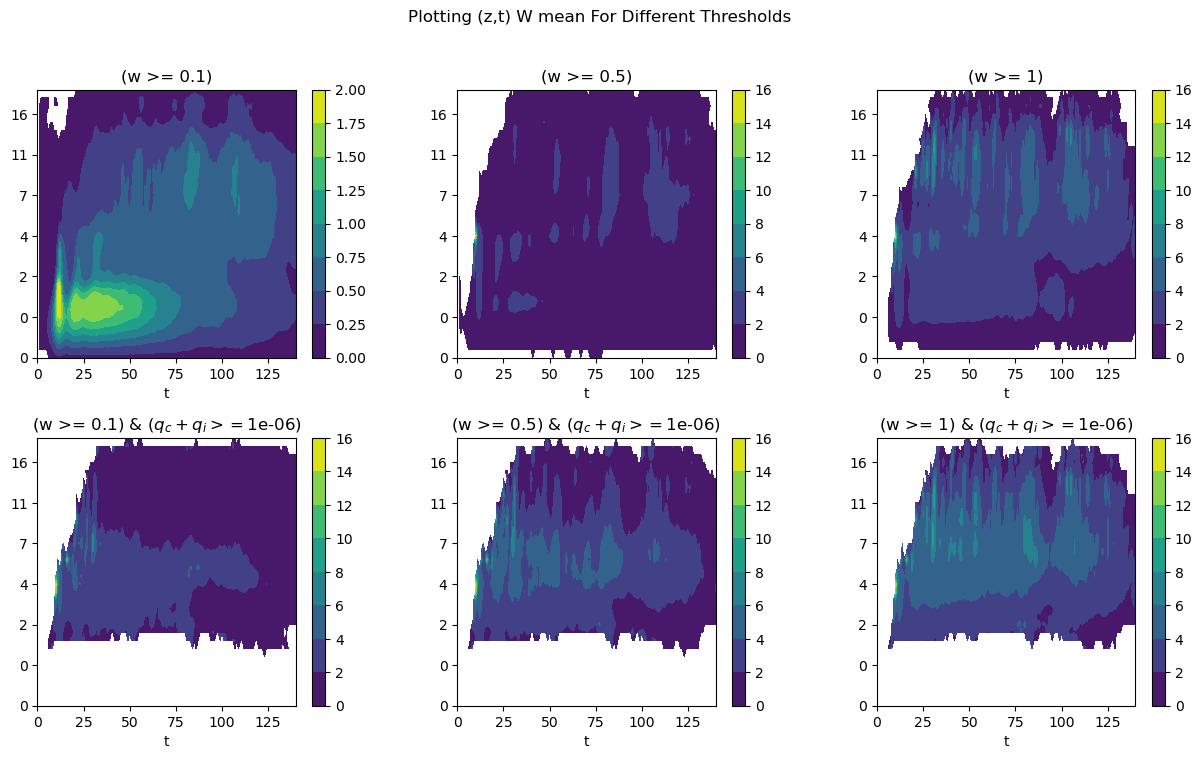

In [96]:
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
c1 = ax1.contourf(w_data_mean1)
fig.colorbar(c1, ax=ax1)
ax1.set_title(f'(w >= {w_thresh1})')

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
c2 = ax2.contourf(w_data_mean2)
fig.colorbar(c2, ax=ax2)
ax2.set_title(f'(w >= {w_thresh2})')

# Third subplot
ax3 = fig.add_subplot(gs[0, 2])
c3 = ax3.contourf(w_data_mean3)
fig.colorbar(c3, ax=ax3)
ax3.set_title(f'(w >= {w_thresh3})')

#########################################


# First subplot
ax4 = fig.add_subplot(gs[1, 0])
c4 = ax4.contourf(w_data_mean4)
fig.colorbar(c4, ax=ax4)
ax4.set_title(f'(w >= {w_thresh1}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')

# Second subplot
ax5 = fig.add_subplot(gs[1, 1])
c5 = ax5.contourf(w_data_mean5)
fig.colorbar(c5, ax=ax5)
ax5.set_title(f'(w >= {w_thresh2}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')

# Third subplot
ax6 = fig.add_subplot(gs[1, 2])
c6 = ax6.contourf(w_data_mean6)
fig.colorbar(c6, ax=ax6)
ax6.set_title(f'(w >= {w_thresh3}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')


#SETTING X AND Y LABELS
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.set_xlabel('t')
    
    zh_values = data['zh'].values
    valid_indices = yticks[(yticks >= 0) & (yticks < len(zh_values))].astype(int)
    new_yticklabels = zh_values[valid_indices]
    axis.set_yticks(valid_indices)  # Ensure ticks are set to valid indices
    axis.set_yticklabels(new_yticklabels.astype(int))  # Update labels


fig.suptitle('Plotting (z,t) W mean For Different Thresholds')

In [ ]:
####################################
#AREA FRACTION PLOTS

In [5]:
w_thresh1=0.1
w_thresh2=0.5
w_thresh3=1
qcqi_thresh=1e-6

In [6]:

where1=np.where(w_data>=w_thresh1)
where2=np.where(w_data>=w_thresh2)
where3=np.where(w_data>=w_thresh3)
where4=np.where((w_data>=w_thresh1) & (qcqi_data>=qcqi_thresh))
where5=np.where((w_data>=w_thresh2) & (qcqi_data>=qcqi_thresh))
where6=np.where((w_data>=w_thresh3) & (qcqi_data>=qcqi_thresh))

In [16]:
Lx=(data['xf'][-1]-data['xf'][0]).values #km
Ly=(data['yf'][-1]-data['yf'][0]).values #km
Area=Lx*Ly

profile1=np.bincount(where1[1])/Area#/np.diff(data['zf'])
profile2=np.bincount(where2[1])/Area#/np.diff(data['zf'])
profile3=np.bincount(where3[1])/Area#/np.diff(data['zf'])
profile4=np.bincount(where4[1])/Area#/np.diff(data['zf'])
profile5=np.bincount(where5[1])/Area#/np.diff(data['zf'])
profile6=np.bincount(where6[1])/Area#/np.diff(data['zf'])

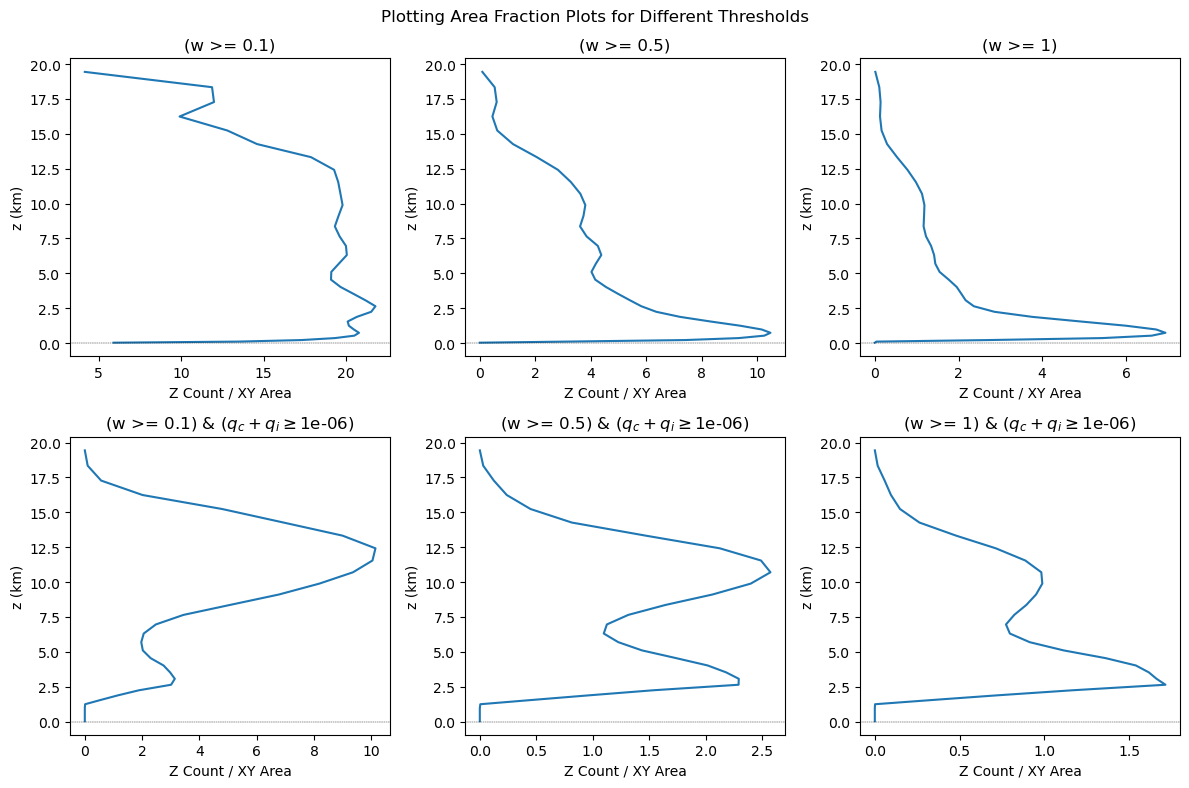

In [17]:
profiles=[profile1,profile2,profile3,profile4,profile5,profile6]
titles = [
    f'(w >= {w_thresh1})', 
    f'(w >= {w_thresh2})', 
    f'(w >= {w_thresh3})',
    f'(w >= {w_thresh1}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh})',
    f'(w >= {w_thresh2}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh})',
    f'(w >= {w_thresh3}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh})'
]

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Create subplots for each profile
axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(profiles[i], data['zh'])
    ax.set_title(titles[i])
    ax.set_xlabel('Z Count / XY Area')
    ax.set_ylabel('z (km)')
    axes.append(ax)
    ax.axhline(color='k',linestyle='dashed',linewidth=0.3)

fig.suptitle('Plotting Area Fraction Plots for Different Thresholds')

fig.tight_layout()


